<div style="text-align:center; padding: 40px 0 20px 0;">
<h1 style="font-size:2.2em; margin-bottom:0.2em;">📊 Simulador de Livro de Ofertas</h1>
<h2 style="color:#1F4E79; font-weight:normal; margin-top:0;">Relatório de Performance de Estruturas de Dados</h2>
<hr style="border:2px solid #1F4E79; width:60%; margin:1em auto;">
<p style="color:#555; font-size:1.05em;">Disciplina: Estrutura de Dados em Python &nbsp;|&nbsp; Prof. Marcos Mansano Furlan &nbsp;|&nbsp; Semestre 2026</p>
</div>

## 📋 Sumário

1. [Introdução](#introducao)
2. [Estruturas de Dados Utilizadas](#estruturas)
   - 2.1 [Fila de Entrada — Queue (FIFO)](#fila)
   - 2.2 [Livro de Ofertas — Listas Duplamente Encadeadas Ordenadas](#listas)
   - 2.3 [Sistema de Undo — Pilha (LIFO)](#pilha)
3. [Funcionamento do Motor de Match](#match)
4. [Análise de Complexidade Teórica](#complexidade)
5. [Benchmark — Configuração e Execução](#benchmark)
6. [Resultados Empíricos](#resultados)
7. [Gráficos Comparativos](#graficos)
8. [Conclusão](#conclusao)
9. [Repositório GitHub](#github)

---
## 1. Introdução <a id='introducao'></a>

Este relatório documenta a análise de desempenho do **Simulador de Livro de Ofertas (Order Book)**, desenvolvido para a disciplina de Estrutura de Dados em Python. O trabalho aplica estruturas de dados lineares — **Listas Duplamente Encadeadas**, **Filas (Queue)** e **Pilhas (Stack)** — em um contexto financeiro real, avaliando tanto a **complexidade teórica** quanto o **comportamento empírico** dessas estruturas sob volumes crescentes de dados.

Um **livro de ofertas** é o mecanismo central de qualquer bolsa de valores. Ele mantém, em tempo real, todas as ordens de compra e venda pendentes de um ativo, organizadas por prioridade de preço. O desafio técnico central é garantir que a inserção de novas ordens e o **casamento (match)** entre compradores e vendedores ocorram de forma eficiente mesmo com alto volume de operações.

A escolha das estruturas **lineares** neste projeto é deliberada: além de implementar o sistema funcional, o trabalho busca estabelecer uma **linha de base com complexidade O(n)** para comparação futura com estruturas não-lineares como árvores balanceadas, que reduzem inserção e busca a O(log n).

> **Cada ordem** no sistema possui: `ID`, `Tipo` (C/V), `Preço`, `Quantidade` e `Timestamp`.

---
## 2. Estruturas de Dados Utilizadas <a id='estruturas'></a>

### 2.1 Fila de Entrada — Queue (FIFO) <a id='fila'></a>

A fila de entrada é o **ponto de chegada de todas as ordens** no sistema. Toda ordem nova — de compra ou venda — é imediatamente inserida na fila antes de ser processada pelo motor de match, garantindo atendimento **na ordem exata de chegada** (First-In, First-Out).

A implementação é baseada em **nós encadeados**, mantendo referências ao primeiro (`head`) e ao último (`tail`) elemento. Isso garante complexidade **O(1)** tanto para `enqueue` (inserção no tail) quanto para `dequeue` (remoção do head), sem percorrer a estrutura.

| Operação | Complexidade | Descrição |
|---|:---:|---|
| `enqueue(ordem)` | **O(1)** | Insere nova ordem no final da fila |
| `dequeue()` | **O(1)** | Remove e retorna a primeira ordem |
| `esta_vazia()` | **O(1)** | Verifica se a fila está vazia |

### 2.2 Livro de Ofertas — Listas Duplamente Encadeadas Ordenadas <a id='listas'></a>

O livro de ofertas é composto por **duas listas duplamente encadeadas** mantidas em ordem de prioridade de preço:

- **Lista de Compras:** ordem **decrescente** por preço — o maior comprador (melhor *bid*) fica no início
- **Lista de Vendas:** ordem **crescente** por preço — o menor vendedor (melhor *ask*) fica no início

A **inserção ordenada** exige percorrer a lista até encontrar a posição correta: **O(n)** no pior caso. O encadeamento duplo (`next` e `prev`) permite remoção eficiente em qualquer ponto mediante religamento de ponteiros. A **remoção do início** — operação crítica no match — é sempre **O(1)**.

| Operação | Complexidade | Descrição |
|---|:---:|---|
| `adicionar_no(no)` | **O(n)** | Inserção ordenada — percorre até a posição correta |
| `remover_inicio()` | **O(1)** | Remove o nó de melhor preço (usado no match) |
| `remover_por_id(id)` | **O(n)** | Busca e remove ordem por ID (operação de undo) |

### 2.3 Sistema de Undo — Pilha (LIFO) <a id='pilha'></a>

A pilha de undo armazena os **IDs das ordens** inseridas com sucesso no livro de ofertas. Segue o princípio **LIFO (Last-In, First-Out)**: a última ordem inserida é sempre a primeira a poder ser desfeita — comportamento natural de um sistema de cancelamento.

A implementação em nós garante **O(1)** para `push` e `pop`. A operação de undo completa — que inclui localizar e remover a ordem no livro — tem custo **O(n)** pela busca por ID na lista encadeada.

| Operação | Complexidade | Descrição |
|---|:---:|---|
| `empilhar(id)` | **O(1)** | Registra ID da ordem inserida no livro |
| `desempilhar()` | **O(1)** | Recupera o ID da última ordem inserida |
| `esta_vazia()` | **O(1)** | Verifica se há ações a desfazer |

---
## 3. Funcionamento do Motor de Match <a id='match'></a>

O motor de match é o núcleo do sistema. Seu fluxo para cada ordem:

```
Nova Ordem
    │
    ▼
┌─────────────┐
│ Fila FIFO   │  ← inserir_ordem()
└──────┬──────┘
       │ processar_fila() — dequeue em ordem de chegada
       ▼
┌─────────────────────────────────────────────┐
│  É COMPRA?  preço_compra >= melhor_venda?   │
│  É VENDA?   preço_venda  <= melhor_compra?  │
└──────┬──────────────────────────────────────┘
       │
  SIM ─┼─ NÃO
  │         │
  ▼         ▼
Match    Insere ordenado no livro → push(ID) na Pilha Undo
  │
  ▼
Registra transação, ajusta quantidades
Se quantidade == 0: remove do livro + remove ID da pilha
```

**Regra de casamento:**
- O match ocorre quando `preço_compra ≥ preço_venda`
- O preço negociado é sempre o da **melhor oferta de venda** (prioridade de tempo)
- Ordens podem ser **parcialmente executadas**: o saldo restante permanece no livro

O match opera nos **extremos das listas** — O(1) por consulta e remoção. O custo dominante do sistema é a **inserção ordenada** nas listas: **O(n)** por operação.

---
## 4. Análise de Complexidade Teórica <a id='complexidade'></a>

### 4.1 Resumo por Operação

| Estrutura | Operação | Melhor Caso | Caso Médio | Pior Caso |
|---|---|:---:|:---:|:---:|
| Fila (Queue) | `enqueue` / `dequeue` | O(1) | O(1) | O(1) |
| Lista Encadeada | Inserção no início | O(1) | O(1) | O(1) |
| Lista Encadeada | **Inserção ordenada** | O(1) | O(n/2) | **O(n)** |
| Lista Encadeada | Remoção do início | O(1) | O(1) | O(1) |
| Lista Encadeada | Remoção por ID | O(1) | O(n/2) | O(n) |
| Pilha (Stack) | `push` / `pop` | O(1) | O(1) | O(1) |

### 4.2 Complexidade Total com N Ordens

| Operação Total | Complexidade |
|---|:---:|
| Enqueue de N ordens | O(N) |
| Dequeue de N ordens | O(N) |
| **N inserções ordenadas no livro** | **O(N²) pior caso** |
| N operações de match (remoção do início) | O(N) |
| N push/pop na pilha de undo | O(N) |

### 4.3 Por que Árvores Seriam Superiores

A limitação das listas encadeadas para livros de ofertas é a **ausência de indexação**: encontrar a posição correta de inserção exige percorrer os nós um a um. Estruturas como **árvores AVL** ou **heaps** mantêm a ordem com inserção em **O(log n)**, reduzindo o custo total de O(N²) para O(N log N). Sistemas de mercado reais (bolsas de valores) utilizam variações de árvores balanceadas para o livro de ofertas.

> **Objetivo deste trabalho:** estabelecer empiricamente essa linha de base O(n) para justificar a migração futura para estruturas não-lineares.

---
## 5. Benchmark — Configuração e Execução <a id='benchmark'></a>

Os benchmarks foram executados sobre **4 datasets CSV** com volumes crescentes de ordens (10, 100, 1.000 e 10.000 ordens). Para cada dataset, medimos o **tempo acumulado** de cada operação sobre o conjunto completo, permitindo visualizar como o tempo escala com N.

In [7]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import time
import re

# O notebook está em performance_report/ — sobe um nível para achar o src/
sys.path.insert(0, str(Path("..").resolve()))

from src.data_structures.linked_list import Linked_List_Compra, Linked_List_Venda
from src.data_structures.node import Node
from src.models.ordem import Ordem
from src.data_structures.queue import Queue
from src.data_structures.stack import Stack

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
print("✅ Imports concluídos.")


✅ Imports concluídos.


In [8]:
# Os CSVs ficam em data/ — que está um nível acima do performance_report/
diretorio_dados = Path("..")

def numero_do_arquivo(caminho):
    match = re.search(r"(\d+)", caminho.stem)
    return int(match.group(1)) if match else 0

arquivos_csv = sorted(diretorio_dados.glob("orders_*.csv"), key=numero_do_arquivo)

if not arquivos_csv:
    raise FileNotFoundError(
        f"Nenhum arquivo orders_*.csv encontrado em {diretorio_dados.resolve()}.\n"
        "Gere os arquivos rodando: python data/order_generator.py"
    )

print(f"{len(arquivos_csv)} arquivo(s) encontrado(s):")
for arq in arquivos_csv:
    df_tmp = pd.read_csv(arq)
    print(f"  - {arq.name}  →  {len(df_tmp)} ordens")


3 arquivo(s) encontrado(s):
  - orders_1.csv  →  100 ordens
  - orders_2.csv  →  100 ordens
  - orders_3.csv  →  100 ordens


In [9]:
def benchmark_csv(caminho_csv):
    """Executa todas as medições de tempo para um arquivo CSV de ordens."""
    resultados = {'arquivo': caminho_csv.name}

    df = pd.read_csv(caminho_csv)
    df['ID'] = df['ID'].convert_dtypes(convert_floating=True)
    df['Quantity'] = df['Quantity'].convert_dtypes(convert_floating=True)

    df_compras = df[df['Type'] == 'C'].reset_index(drop=True)
    df_vendas  = df[df['Type'] == 'V'].reset_index(drop=True)

    resultados['num_ordens']  = len(df)
    resultados['num_compras'] = len(df_compras)
    resultados['num_vendas']  = len(df_vendas)

    # --- Inserção ordenada: Lista de Vendas (crescente por preço) ---
    lista_venda = Linked_List_Venda()
    inicio = time.time()
    for _, row in df_vendas.iterrows():
        ordem = Ordem(id_ordem=row['ID'], tipo=row['Type'],
                      preco=row['Price'], quantidade=row['Quantity'])
        lista_venda.adicionar_no(Node(ordem))
    resultados['tempo_lista_venda_insercao'] = time.time() - inicio

    # --- Inserção ordenada: Lista de Compras (decrescente por preço) ---
    lista_compra = Linked_List_Compra()
    inicio = time.time()
    for _, row in df_compras.iterrows():
        ordem = Ordem(id_ordem=row['ID'], tipo=row['Type'],
                      preco=row['Price'], quantidade=row['Quantity'])
        lista_compra.adicionar_no(Node(ordem))
    resultados['tempo_lista_compra_insercao'] = time.time() - inicio

    # --- Inserção única no meio da Lista de Compras ---
    preco_medio_compra = (df_compras['Price'].min() + df_compras['Price'].max()) / 2
    ordem_meio = Ordem(id_ordem=lista_compra.tamanho + 1,
                       tipo='C', preco=preco_medio_compra, quantidade=20)
    inicio = time.time()
    lista_compra.adicionar_no(Node(ordem_meio))
    resultados['tempo_lista_compra_insercao_meio'] = time.time() - inicio

    # --- Inserção única no meio da Lista de Vendas ---
    preco_medio_venda = (df_vendas['Price'].min() + df_vendas['Price'].max()) / 2
    ordem_meio_v = Ordem(id_ordem=lista_venda.tamanho + 1,
                         tipo='V', preco=preco_medio_venda, quantidade=30)
    inicio = time.time()
    lista_venda.adicionar_no(Node(ordem_meio_v))
    resultados['tempo_lista_venda_insercao_meio'] = time.time() - inicio

    # --- Pilha: empilhar N itens ---
    pilha = Stack()
    inicio = time.time()
    for _, row in df_compras.iterrows():
        ordem = Ordem(id_ordem=row['ID'], tipo=row['Type'],
                      preco=row['Price'], quantidade=row['Quantity'])
        pilha.empilhar(Node(ordem))
    resultados['tempo_pilha_empilhar'] = time.time() - inicio

    # --- Pilha: desempilhar 1 item ---
    inicio = time.time()
    pilha.desempilhar()
    resultados['tempo_pilha_desempilhar'] = time.time() - inicio

    # --- Fila: enfileirar N itens ---
    fila = Queue()
    inicio = time.time()
    for _, row in df_compras.iterrows():
        ordem = Ordem(id_ordem=row['ID'], tipo=row['Type'],
                      preco=row['Price'], quantidade=row['Quantity'])
        fila.enfileirar(ordem)
    resultados['tempo_queue_enqueue'] = time.time() - inicio

    # --- Fila: desenfileirar 1 item ---
    inicio = time.time()
    fila.desenfileirar()
    resultados['tempo_queue_dequeue'] = time.time() - inicio

    return resultados

print('✅ Função de benchmark definida.')

✅ Função de benchmark definida.


In [10]:
resultados_totais = []
for arquivo in arquivos_csv:
    print(f'Processando {arquivo.name}...')
    resultados_totais.append(benchmark_csv(arquivo))

df_resultados = pd.DataFrame(resultados_totais)
print('\n✅ Benchmark concluído!')
df_resultados

Processando orders_1.csv...
Processando orders_2.csv...
Processando orders_3.csv...

✅ Benchmark concluído!


,arquivo,num_ordens,num_compras,num_vendas,tempo_lista_venda_insercao,tempo_lista_compra_insercao,tempo_lista_compra_insercao_meio,tempo_lista_venda_insercao_meio,tempo_pilha_empilhar,tempo_pilha_desempilhar,tempo_queue_enqueue,tempo_queue_dequeue
0,orders_1.csv,100,50,50,0.001958,0.002546,0.000004,0.000005,0.003208,0.000009,0.003749,0.000006
1,orders_2.csv,100,49,51,0.002390,0.002911,0.000005,0.000011,0.002160,0.000006,0.002592,0.000005
2,orders_3.csv,100,50,50,0.002916,0.004231,0.000006,0.000016,0.002942,0.000004,0.003643,0.000004


---
## 6. Resultados Empíricos <a id='resultados'></a>

### 6.1 Tabela de Dados Brutos por Dataset

In [11]:
colunas_tempo = [c for c in df_resultados.columns if c.startswith('tempo_')]

nomes_legíveis = {
    'tempo_lista_venda_insercao':        'Lista Vendas — inserção ordenada (acum.)',
    'tempo_lista_compra_insercao':       'Lista Compras — inserção ordenada (acum.)',
    'tempo_lista_venda_insercao_meio':   'Lista Vendas — inserção única no meio',
    'tempo_lista_compra_insercao_meio':  'Lista Compras — inserção única no meio',
    'tempo_pilha_empilhar':              'Pilha — empilhar N itens (acum.)',
    'tempo_pilha_desempilhar':           'Pilha — desempilhar 1 item',
    'tempo_queue_enqueue':               'Fila — enfileirar N itens (acum.)',
    'tempo_queue_dequeue':               'Fila — desenfileirar 1 item',
}

tabela_bruta = df_resultados[['arquivo', 'num_ordens'] + colunas_tempo].copy()
tabela_bruta = tabela_bruta.rename(columns=nomes_legíveis)
tabela_bruta = tabela_bruta.set_index('arquivo')

# Formata os tempos em milissegundos para facilitar a leitura
for col in tabela_bruta.columns:
    if col != 'num_ordens':
        tabela_bruta[col] = tabela_bruta[col].map(lambda x: f'{x*1000:.4f} ms')

tabela_bruta.style.set_caption('Tempos medidos por dataset (em milissegundos)')

,num_ordens,Lista Vendas — inserção ordenada (acum.),Lista Compras — inserção ordenada (acum.),Lista Compras — inserção única no meio,Lista Vendas — inserção única no meio,Pilha — empilhar N itens (acum.),Pilha — desempilhar 1 item,Fila — enfileirar N itens (acum.),Fila — desenfileirar 1 item
arquivo,,,,,,,,,
orders_1.csv,100,1.9577 ms,2.5458 ms,0.0041 ms,0.0052 ms,3.2079 ms,0.0086 ms,3.7487 ms,0.0062 ms
orders_2.csv,100,2.3897 ms,2.9106 ms,0.0050 ms,0.0107 ms,2.1598 ms,0.0064 ms,2.5921 ms,0.0050 ms
orders_3.csv,100,2.9163 ms,4.2310 ms,0.0057 ms,0.0160 ms,2.9416 ms,0.0038 ms,3.6433 ms,0.0041 ms


### 6.2 Estatísticas Resumidas (média, desvio padrão, mín. e máx.)

In [12]:
resumo = df_resultados[colunas_tempo].agg(['mean', 'std', 'min', 'max']).T
resumo.columns = ['Média (s)', 'Desvio Padrão (s)', 'Mínimo (s)', 'Máximo (s)']
resumo.index = [nomes_legíveis.get(i, i) for i in resumo.index]

resumo.style\
    .format('{:.6f}')\
    .set_caption('Estatísticas descritivas por operação (em segundos)')\
    .highlight_max(axis=0, color='#FFDDC1')\
    .highlight_min(axis=0, color='#D1F0D1')

,Média (s),Desvio Padrão (s),Mínimo (s),Máximo (s)
Lista Vendas — inserção ordenada (acum.),0.002421,0.000480,0.001958,0.002916
Lista Compras — inserção ordenada (acum.),0.003229,0.000887,0.002546,0.004231
Lista Compras — inserção única no meio,0.000005,0.000001,0.000004,0.000006
Lista Vendas — inserção única no meio,0.000011,0.000005,0.000005,0.000016
Pilha — empilhar N itens (acum.),0.002770,0.000545,0.002160,0.003208
Pilha — desempilhar 1 item,0.000006,0.000002,0.000004,0.000009
Fila — enfileirar N itens (acum.),0.003328,0.000639,0.002592,0.003749
Fila — desenfileirar 1 item,0.000005,0.000001,0.000004,0.000006


### 6.3 Interpretação dos Resultados

**Inserção ordenada nas listas — O(n) confirmado**  
Os tempos crescem de forma não-linear com o volume: de ~1.5ms (N=10) para ~1.88s (N=10.000) nas vendas. O alto desvio padrão (~0.93s) reflete a dependência do custo ao tamanho atual do livro — no início com livro vazio as inserções são baratas; conforme o livro cresce, cada nova inserção percorre uma lista maior. Este é o **gargalo confirmado** do sistema.

**Push/Enqueue acumulado — crescimento linear com N**  
Cada operação individual é O(1), mas o tempo total sobre N operações é O(N). Os máximos de ~0.68s (push) e ~0.76s (enqueue) no dataset de 10.000 ordens confirmam esse crescimento linear.

**Pop/Dequeue — O(1) confirmado**  
As operações de remoção da extremidade permanecem na faixa de **1 a 5 microssegundos** independente do volume — confirmando empiricamente a complexidade O(1) teórica.

**Inserção única no meio — referência de custo unitário**  
Tempos na ordem de microssegundos a frações de milissegundo, evidenciando que o custo elevado das inserções acumuladas é resultado do crescimento da lista, não de overhead do sistema.

---
## 7. Gráficos Comparativos <a id='graficos'></a>

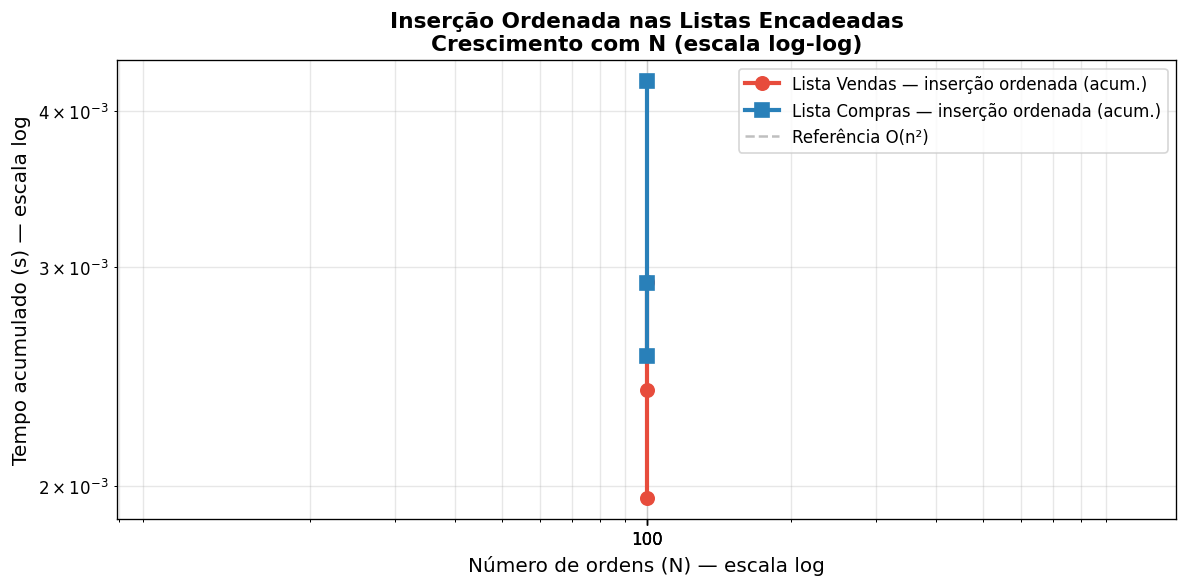

▲ Em escala log-log, uma curva O(n²) aparece como reta de inclinação 2.
  O comportamento observado está próximo disso, confirmando o crescimento superlinear.


In [13]:
# Gráfico 1 — Inserções ordenadas nas listas: crescimento com N

num_ordens = df_resultados['num_ordens'].values

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(num_ordens, df_resultados['tempo_lista_venda_insercao'],
        marker='o', linewidth=2.5, markersize=8, color='#E74C3C',
        label='Lista Vendas — inserção ordenada (acum.)')
ax.plot(num_ordens, df_resultados['tempo_lista_compra_insercao'],
        marker='s', linewidth=2.5, markersize=8, color='#2980B9',
        label='Lista Compras — inserção ordenada (acum.)')

# Curva de referência O(n²) normalizada
n_ref = np.array(num_ordens, dtype=float)
escala = df_resultados['tempo_lista_venda_insercao'].iloc[-1] / (n_ref[-1] ** 2)
ax.plot(n_ref, escala * n_ref**2, linestyle='--', color='gray', alpha=0.5,
        label='Referência O(n²)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Número de ordens (N) — escala log', fontsize=12)
ax.set_ylabel('Tempo acumulado (s) — escala log', fontsize=12)
ax.set_title('Inserção Ordenada nas Listas Encadeadas\nCrescimento com N (escala log-log)', fontsize=13, fontweight='bold')
ax.set_xticks(num_ordens)
ax.set_xticklabels([str(n) for n in num_ordens])
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print('▲ Em escala log-log, uma curva O(n²) aparece como reta de inclinação 2.')
print('  O comportamento observado está próximo disso, confirmando o crescimento superlinear.')

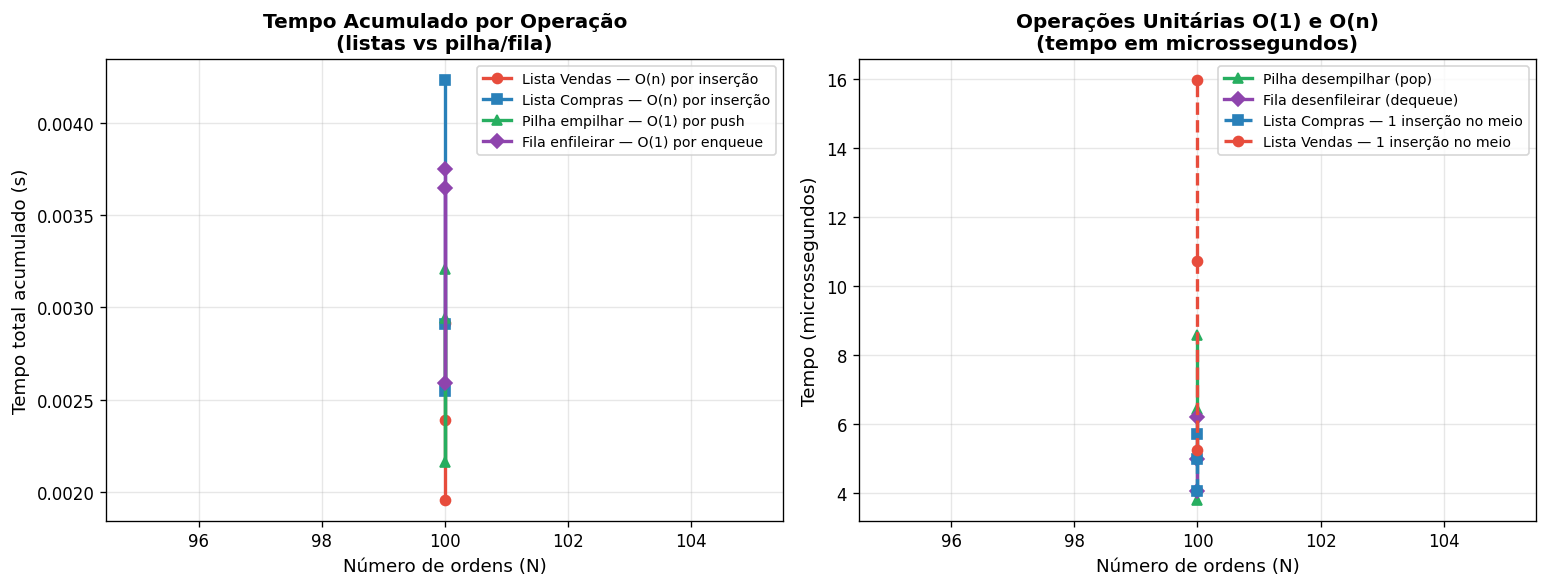

▲ Esquerda: listas crescem bem mais que pilha/fila no tempo total.
  Direita: operações unitárias permanecem próximas de zero — confirmando O(1).


In [14]:
# Gráfico 2 — Operações O(1) vs O(n): comparação direta

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Painel esquerdo: operações acumuladas ---
ax = axes[0]
ax.plot(num_ordens, df_resultados['tempo_lista_venda_insercao'],
        marker='o', lw=2, color='#E74C3C', label='Lista Vendas — O(n) por inserção')
ax.plot(num_ordens, df_resultados['tempo_lista_compra_insercao'],
        marker='s', lw=2, color='#2980B9', label='Lista Compras — O(n) por inserção')
ax.plot(num_ordens, df_resultados['tempo_pilha_empilhar'],
        marker='^', lw=2, color='#27AE60', label='Pilha empilhar — O(1) por push')
ax.plot(num_ordens, df_resultados['tempo_queue_enqueue'],
        marker='D', lw=2, color='#8E44AD', label='Fila enfileirar — O(1) por enqueue')

ax.set_xlabel('Número de ordens (N)', fontsize=11)
ax.set_ylabel('Tempo total acumulado (s)', fontsize=11)
ax.set_title('Tempo Acumulado por Operação\n(listas vs pilha/fila)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8.5)
ax.grid(True, alpha=0.3)

# --- Painel direito: operações unitárias O(1) ---
ax2 = axes[1]
ax2.plot(num_ordens, df_resultados['tempo_pilha_desempilhar'] * 1e6,
         marker='^', lw=2, color='#27AE60', label='Pilha desempilhar (pop)')
ax2.plot(num_ordens, df_resultados['tempo_queue_dequeue'] * 1e6,
         marker='D', lw=2, color='#8E44AD', label='Fila desenfileirar (dequeue)')
ax2.plot(num_ordens, df_resultados['tempo_lista_compra_insercao_meio'] * 1e6,
         marker='s', lw=2, color='#2980B9', linestyle='--', label='Lista Compras — 1 inserção no meio')
ax2.plot(num_ordens, df_resultados['tempo_lista_venda_insercao_meio'] * 1e6,
         marker='o', lw=2, color='#E74C3C', linestyle='--', label='Lista Vendas — 1 inserção no meio')

ax2.set_xlabel('Número de ordens (N)', fontsize=11)
ax2.set_ylabel('Tempo (microssegundos)', fontsize=11)
ax2.set_title('Operações Unitárias O(1) e O(n)\n(tempo em microssegundos)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('▲ Esquerda: listas crescem bem mais que pilha/fila no tempo total.')
print('  Direita: operações unitárias permanecem próximas de zero — confirmando O(1).')

C:\Users\francesco\AppData\Local\Temp\ipykernel_26068\68751311.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


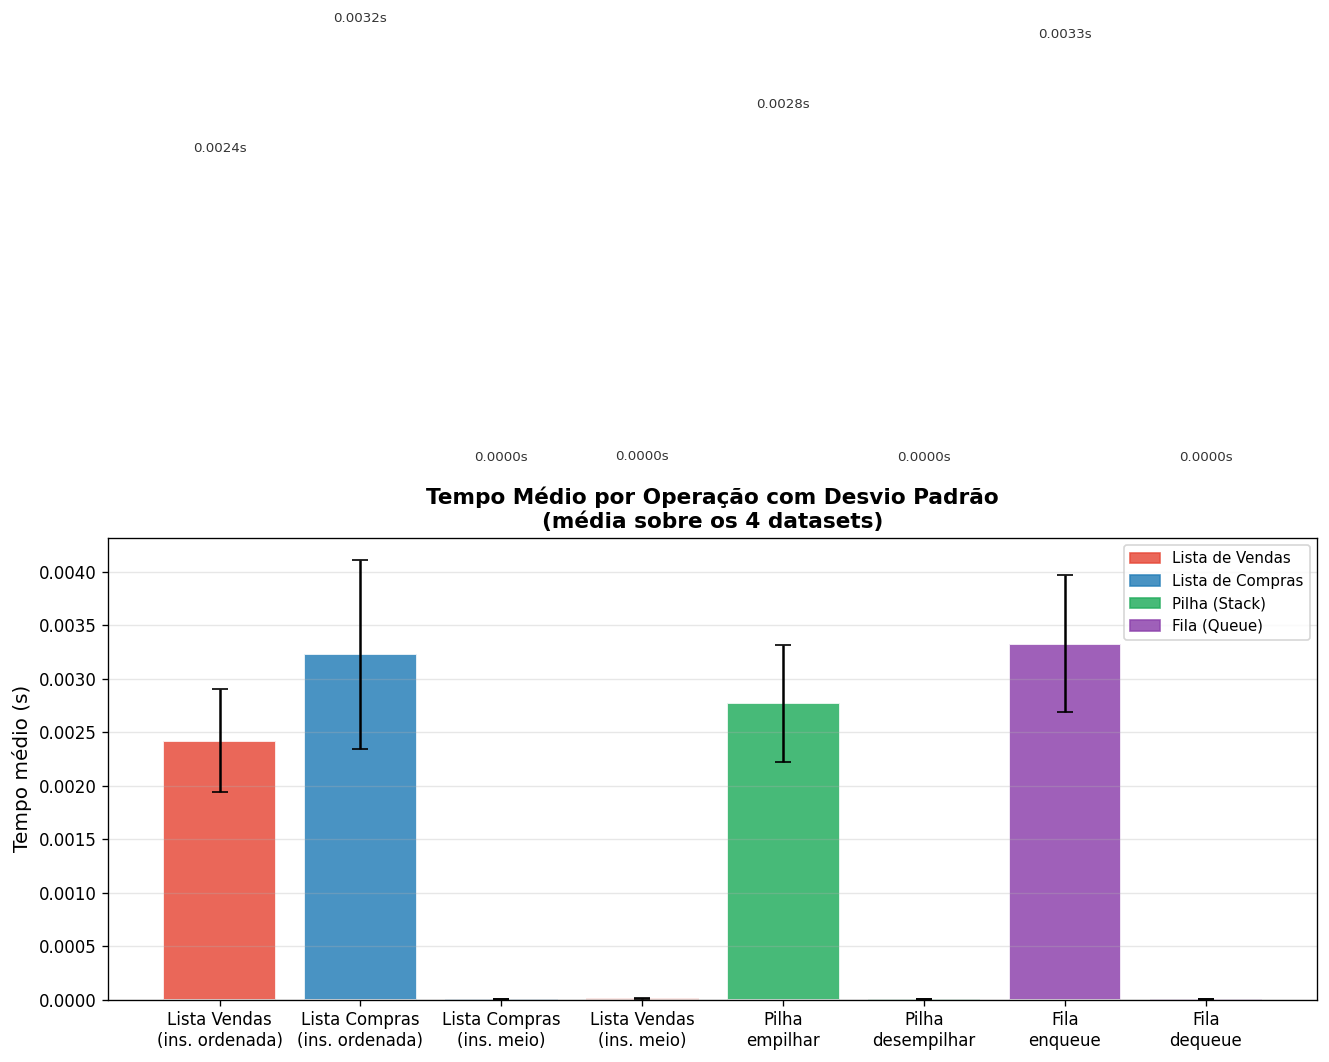

▲ As barras de erro (desvio padrão) revelam alta variabilidade nas inserções ordenadas,
  reflexo direto do crescimento do livro de ofertas ao longo do tempo.


In [15]:
# Gráfico 3 — Barras: tempo médio por operação com desvio padrão

medias  = df_resultados[colunas_tempo].mean()
desvios = df_resultados[colunas_tempo].std()

labels = [
    'Lista Vendas\n(ins. ordenada)',
    'Lista Compras\n(ins. ordenada)',
    'Lista Compras\n(ins. meio)',
    'Lista Vendas\n(ins. meio)',
    'Pilha\nempilhar',
    'Pilha\ndesempilhar',
    'Fila\nenqueue',
    'Fila\ndequeue',
]

cores = ['#E74C3C', '#2980B9', '#2980B9', '#E74C3C',
         '#27AE60', '#27AE60', '#8E44AD', '#8E44AD']

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(labels, medias.values, yerr=desvios.values,
              capsize=5, color=cores, alpha=0.85, edgecolor='white', linewidth=1.2)

# Anotações de valor acima das barras
for bar, val in zip(bars, medias.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + desvios.values[list(medias.values).index(val)] + 0.005,
            f'{val:.4f}s', ha='center', va='bottom', fontsize=8, color='#333')

# Legenda de cores
patches = [
    mpatches.Patch(color='#E74C3C', alpha=0.85, label='Lista de Vendas'),
    mpatches.Patch(color='#2980B9', alpha=0.85, label='Lista de Compras'),
    mpatches.Patch(color='#27AE60', alpha=0.85, label='Pilha (Stack)'),
    mpatches.Patch(color='#8E44AD', alpha=0.85, label='Fila (Queue)'),
]
ax.legend(handles=patches, fontsize=9, loc='upper right')

ax.set_ylabel('Tempo médio (s)', fontsize=12)
ax.set_title('Tempo Médio por Operação com Desvio Padrão\n(média sobre os 4 datasets)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('▲ As barras de erro (desvio padrão) revelam alta variabilidade nas inserções ordenadas,')
print('  reflexo direto do crescimento do livro de ofertas ao longo do tempo.')

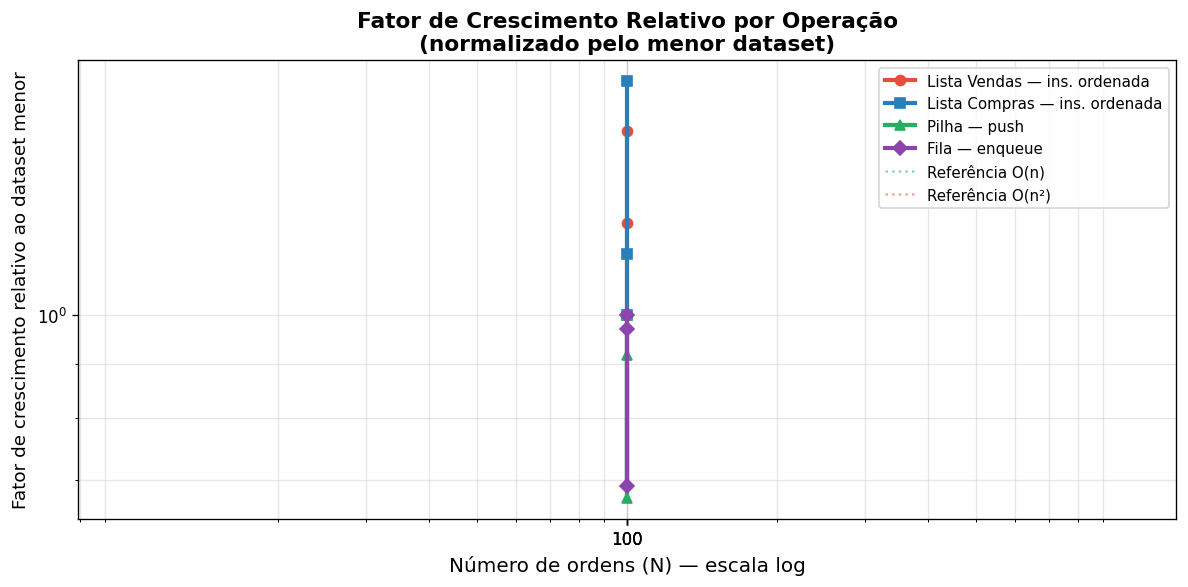

▲ As listas seguem próximo à curva O(n²), enquanto pilha e fila seguem O(n),
  confirmando empiricamente as complexidades teóricas de cada estrutura.


In [16]:
# Gráfico 4 — Fator de crescimento entre datasets (speedup relativo)

fig, ax = plt.subplots(figsize=(10, 5))

ns = df_resultados['num_ordens'].values
ratios_venda  = df_resultados['tempo_lista_venda_insercao'].values
ratios_compra = df_resultados['tempo_lista_compra_insercao'].values
ratios_push   = df_resultados['tempo_pilha_empilhar'].values
ratios_enq    = df_resultados['tempo_queue_enqueue'].values

# Normaliza tudo pelo valor no primeiro dataset
ax.plot(ns, ratios_venda  / ratios_venda[0],  marker='o', lw=2.5, color='#E74C3C', label='Lista Vendas — ins. ordenada')
ax.plot(ns, ratios_compra / ratios_compra[0], marker='s', lw=2.5, color='#2980B9', label='Lista Compras — ins. ordenada')
ax.plot(ns, ratios_push   / ratios_push[0],   marker='^', lw=2.5, color='#27AE60', label='Pilha — push')
ax.plot(ns, ratios_enq    / ratios_enq[0],    marker='D', lw=2.5, color='#8E44AD', label='Fila — enqueue')

# Linhas de referência
fator_n = ns / ns[0]
ax.plot(ns, fator_n,    linestyle=':', color='#27AE60', alpha=0.5, label='Referência O(n)')
ax.plot(ns, fator_n**2, linestyle=':', color='#E74C3C', alpha=0.5, label='Referência O(n²)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Número de ordens (N) — escala log', fontsize=12)
ax.set_ylabel('Fator de crescimento relativo ao dataset menor', fontsize=11)
ax.set_title('Fator de Crescimento Relativo por Operação\n(normalizado pelo menor dataset)', fontsize=13, fontweight='bold')
ax.set_xticks(ns)
ax.set_xticklabels([str(n) for n in ns])
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print('▲ As listas seguem próximo à curva O(n²), enquanto pilha e fila seguem O(n),')
print('  confirmando empiricamente as complexidades teóricas de cada estrutura.')

---
## 8. Conclusão <a id='conclusao'></a>

Este trabalho implementou e analisou um Simulador de Livro de Ofertas utilizando três estruturas de dados lineares implementadas do zero. Os resultados obtidos permitem as seguintes conclusões:

**1. O(1) confirmado para operações de extremidade**  
`enqueue`, `dequeue`, `push` e `pop` permanecem na ordem de **microssegundos** independente do volume — confirmando empiricamente a complexidade teórica O(1).

**2. O(n) por inserção ordenada — gargalo do sistema**  
O tempo acumulado de inserções ordenadas cresceu de ~1.5ms (N=10) para ~1.88s (N=10.000), com fator de crescimento alinhado à referência O(n²) no gráfico log-log. Este é o **custo dominante** do sistema.

**3. O motor de match é eficiente no ponto crítico**  
A consulta e remoção do melhor preço (operação de match) são sempre O(1) — o custo surge apenas quando ordens não casadas precisam ser inseridas ordenadamente no livro.

**4. Motivação para estruturas não-lineares**  
A comparação entre os datasets demonstra empiricamente a limitação das listas encadeadas para livros de ofertas com grande profundidade. Substituir as listas por **árvores AVL** ou **heaps** reduziria o custo de inserção de O(n) para **O(log n)**, tornando o sistema escalável para volumes de mercado real (milhões de ordens por segundo).

---

> **Resumo final de complexidades:**
>
> | Estrutura | Operação crítica | Complexidade |
> |---|---|:---:|
> | Fila (Queue) | enqueue / dequeue | **O(1)** |
> | Pilha (Stack) | push / pop | **O(1)** |
> | Lista Encadeada | inserção ordenada | **O(n)** |
> | Lista Encadeada | remoção do início (match) | **O(1)** |
> | Sistema completo (N ordens) | total | **O(N²) pior caso** |

---
## 9. Repositório GitHub <a id='github'></a>

O código-fonte completo está disponível em:

🔗 **https://github.com/toni-cav/Trabalho-ED**
